### Fase 1 Exploración

Estudiante: Ivan Ramiro Quiroga Castañeda

Objetivo: Limpieza, creación de variables, totales por factura, top invoice, top customer, tratamiento de outliers y visualización de distribución.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


### Carga y exploración inicial

En esta parte cargo el archivo CSV y reviso rápidamente su estructura (número de filas/columnas, tipos de datos y presencia de valores faltantes), esto me ayuda a decidir qué limpieza debo aplicar antes de calcular métricas de ventas.

In [31]:
path = "Appendix 1 - Database.csv"
df = pd.read_csv(path, encoding="latin1")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Observación inicial del dataset

El dataset contiene variables típicas de transacciones como número de factura (InvoiceNo), código y descripción del producto, cantidad, fecha de factura, precio unitario, cliente y país. En CustomerID se observan valores faltantes, por lo que más adelante haré el análisis de “top customer” con los registros que sí tienen identificador.

In [32]:
print("Dimensión (filas, columnas):", df.shape)
df.info()
df.describe(include="all").T

Dimensión (filas, columnas): (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza básica

Para que el cálculo de ventas sea coherente, elimino filas con Quantity <= 0 o UnitPrice <= 0, considero que este tipo de datos, valores negativos o cero suelen corresponder a devoluciones o cancelaciones o registros no válidos la cual mantenerlos afectaría el total por factura y el análisis de clientes.

In [33]:
# Convertir fecha manteniendo coherencia de formato DD/MM/YYYY en el reporte
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Copia limpia inicial
df_clean = df.dropna(subset=["InvoiceNo", "Quantity", "UnitPrice"]).copy()

# Quitar registros inválidos
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

print("Filas originales:", len(df))
print("Filas después de limpieza básica:", len(df_clean))


Filas originales: 541909
Filas después de limpieza básica: 530104


In [37]:
# Mantener formato DD/MM/YYYY
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")
df_clean["InvoiceDate_str"] = df_clean["InvoiceDate"].dt.strftime("%d/%m/%Y %H:%M")
df_clean[["InvoiceDate", "InvoiceDate_str"]].head()


,InvoiceDate,InvoiceDate_str
0,2010-12-01 08:26:00,01/12/2010 08:26
1,2010-12-01 08:26:00,01/12/2010 08:26
2,2010-12-01 08:26:00,01/12/2010 08:26
3,2010-12-01 08:26:00,01/12/2010 08:26
4,2010-12-01 08:26:00,01/12/2010 08:26


### Ingeniería de variables

Creo la variable TotalPrice como Quantity × UnitPrice, esta variable representa el valor monetario por línea de producto y es la base para calcular totales por factura y gasto por cliente.

In [38]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice"]].head()


,InvoiceNo,Quantity,UnitPrice,TotalPrice
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


### Totales por factura

Agrego el dataset por InvoiceNo para obtener InvoiceTotal (suma de TotalPrice), esto me permite analizar el ticket de compra y comparar facturas.

In [39]:
invoice_totals = (
    df_clean.groupby("InvoiceNo", as_index=False)["TotalPrice"]
    .sum()
    .rename(columns={"TotalPrice": "InvoiceTotal"})
)

invoice_totals.head(), invoice_totals["InvoiceTotal"].describe()


(  InvoiceNo  InvoiceTotal
 0    536365        139.12
 1    536366         22.20
 2    536367        278.73
 3    536368         70.05
 4    536369         17.85,
 count     19960.000000
 mean        534.403033
 std        1780.487648
 min           0.380000
 25%         152.510000
 50%         303.835000
 75%         495.615000
 max      168469.600000
 Name: InvoiceTotal, dtype: float64)

## Tratamiento de valores atípicos

Para detectar outliers uso el criterio IQR porque es una regla simple y robusta cuando la distribución es asimétrica (cola larga), se consideran outliers los valores mayores a Q3 + 1.5×IQR.
En mi caso obtuve: Q1=152.51, Q3=495.615 e IQR=343.105, por lo que el umbral superior fue ≈ 1010.27, al aplicar esta regla, aproximadamente 9.07% de las facturas quedaron como atípicas.

In [40]:
q1 = invoice_totals["InvoiceTotal"].quantile(0.25)
q3 = invoice_totals["InvoiceTotal"].quantile(0.75)
iqr = q3 - q1

lower = max(0, q1 - 1.5*iqr)
upper = q3 + 1.5*iqr

outliers = invoice_totals[(invoice_totals["InvoiceTotal"] < lower) | (invoice_totals["InvoiceTotal"] > upper)]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower:", lower)
print("Upper:", upper)
print("Número de facturas outlier:", len(outliers), "de", len(invoice_totals))
print("Proporción outliers:", len(outliers)/len(invoice_totals))


Q1: 152.51
Q3: 495.615
IQR: 343.105
Lower: 0
Upper: 1010.2725
Número de facturas outlier: 1811 de 19960
Proporción outliers: 0.0907314629258517


### Filtrar outliers y recalcular totales

Después de identificar las facturas atípicas con IQR, filtro el dataset para conservar únicamente las facturas dentro del rango permitido (InvoiceTotal entre 0 y 1010.27).
La razón de hacerlo a nivel de factura es que el outlier se detecta en el total de la factura, no en una sola línea de producto, por eso primero creo la lista invoices_keep con los InvoiceNo válidos y luego filtro las filas originales usando isin(), finalmente, recalculo InvoiceTotal con el dataset filtrado para asegurar que los estadísticos y el histograma representen el comportamiento típico sin distorsión por compras excepcionalmente grandes.
Esto no significa que la compra sea mala, sino que para describir el patrón general prefiero separarlas del análisis principal.

In [41]:
invoices_keep = invoice_totals[
    (invoice_totals["InvoiceTotal"] >= lower) & (invoice_totals["InvoiceTotal"] <= upper)
]["InvoiceNo"]

df_no_out = df_clean[df_clean["InvoiceNo"].isin(invoices_keep)].copy()

invoice_totals_no = (
    df_no_out.groupby("InvoiceNo", as_index=False)["TotalPrice"]
    .sum()
    .rename(columns={"TotalPrice": "InvoiceTotal"})
)

invoice_totals_no["InvoiceTotal"].describe()


count    18149.000000
mean       307.136128
std        217.691331
min          0.380000
25%        141.490000
50%        278.670000
75%        415.250000
max       1009.800000
Name: InvoiceTotal, dtype: float64

### Factura de mayor total y top customer

Con los datos sin outliers recalculo los totales y busco la factura con mayor valor, para el top customer uso dos criterios: (1) gasto total acumulado y (2) número de facturas (frecuencia), esto me ayuda a diferenciar entre un cliente que compra poco pero muy seguido y uno que hace compras grandes.

Criterio elegido: En este análisis considero “top customer” al cliente con mayor gasto total, ya que es el criterio más directo para identificar clientes de alto valor económico para la empresa.

In [42]:
top_invoice = invoice_totals_no.sort_values("InvoiceTotal", ascending=False).head(5)
top_invoice


,InvoiceNo,InvoiceTotal
2363,542713,1009.80
5638,550899,1009.69
12155,566869,1009.27
7725,555896,1008.61
5620,550822,1007.90


### Top customer

In [43]:
df_no_out_cust = df_no_out.dropna(subset=["CustomerID"]).copy()

cust_spend = (
    df_no_out_cust.groupby("CustomerID", as_index=False)["TotalPrice"]
    .sum()
    .rename(columns={"TotalPrice": "CustomerTotalSpend"})
)

cust_invoices = (
    df_no_out_cust.groupby("CustomerID", as_index=False)["InvoiceNo"]
    .nunique()
    .rename(columns={"InvoiceNo": "NumInvoices"})
)

top_spender = cust_spend.sort_values("CustomerTotalSpend", ascending=False).head(5)
top_invoicer = cust_invoices.sort_values("NumInvoices", ascending=False).head(5)

top_spender, top_invoicer


(      CustomerID  CustomerTotalSpend
 1826     14911.0            80456.79
 3920     17841.0            40991.57
 2117     15311.0            34028.28
 532      13089.0            32141.46
 303      12748.0            27945.96,
       CustomerID  NumInvoices
 303      12748.0          205
 1826     14911.0          163
 3920     17841.0          124
 1609     14606.0           93
 451      12971.0           86)

Además del valor máximo, reviso el Top 5 de facturas y clientes para ver si el mayor caso es aislado o si existen varios valores cercanos al umbral, esto me ayuda a entender si el patrón de compras altas es frecuente o excepcional.

### Visualización – Distribución del total por factura

Grafico un histograma de InvoiceTotal (sin outliers) para observar la forma de la distribución, busco identificar si hay sesgo, concentración de tickets y cola hacia valores altos, lo cual es útil para segmentación y estrategias de marketing.

Seleccioné 50 bins para balancear detalle y legibilidad en donde permite observar la forma general (asimetría y cola larga) sin que el gráfico quede excesivamente ruidoso o difícil de interpretar.

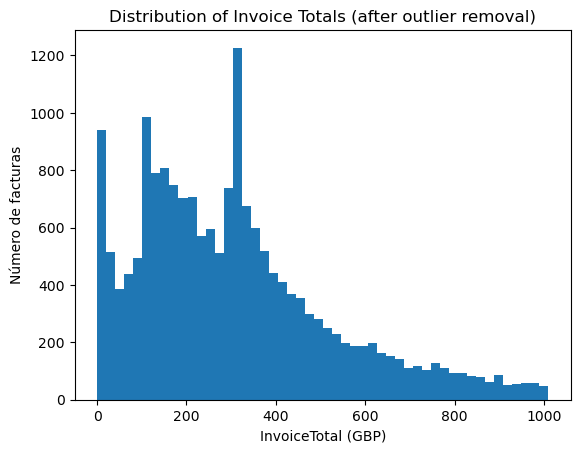

In [45]:
plt.figure()
plt.hist(invoice_totals_no["InvoiceTotal"], bins=50)
plt.xlabel("InvoiceTotal (GBP)")
plt.ylabel("Número de facturas")
plt.title("Distribution of Invoice Totals (after outlier removal)")
plt.show()


Se grafica un histograma para observar la forma de los totales por factura, el eje X representa el valor monetario total por factura (GBP) y el eje Y representa el número de facturas, este gráfico permite identificar asimetría (cola larga) y apoyar decisiones de segmentación.

### Conclusiones

La distribución del total por factura es claramente asimétrica: hay muchas compras de bajo/medio valor y pocas facturas cercanas al umbral superior.

Para marketing, esto sugiere que conviene definir estrategias por rangos de ticket (por ejemplo: incentivos para subir el ticket promedio).

Identifiqué un cliente con gasto acumulado muy alto (CustomerID 14911) y otro con alta frecuencia (CustomerID 12748), podria tratarse con estrategias diferentes (VIP vs fidelización por recurrencia).

Limitación: al remover outliers se podrían eliminar compras legítimas tipo “mayorista”; como mejora, haría un análisis adicional segmentando por país o por frecuencia para ver si hay perfiles distintos.